In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.typing import ArrayLike
from typing import Dict, Any, Union 

def auc_roc(y_true: ArrayLike, scores: ArrayLike, thresholds: int= 50, show_plot: bool = True) -> Dict[str, Union[np.ndarray, float]]:

    """
    
    Cálculo del AUC ROC y optimización del umbral

    Calcula la curva ROC barriendo una serie de umbrales y determina el mejor punto de corte basado en la distancia mínima al punto ideal (0,1). 
    También genera una visualización de la curva. 


    :param y_true: targets de clase (0 o 1).
    :type y_true: ArrayLike 
    :param scores: probabilidad de scores o probabilidades asignados por el modelo.
    :type scores: ArrayLike
    :param thresholds: número de umbrales a evaluar, por defecto 50.
    :type thresholds: int
    :param show_plot: Generar visualización de la AUC ROC.
    :type: bool
    :return: Diccionario con TVP, TFP (arrays), valor AUC y mejor_umbral (floats).
    :rtype: Dict[str, Union[np.ndarray, float]]
    :authors: Emiliano David Santis
    :date: 4/05/2026

    """

    # Validamos las entradas cambiar el actual
    #_validacion_inputs(y_true, scores)

    if len(y_true) != len(scores):
        raise ValueError("y_true y scores deben tener la misma longitud.")

    # Convertimos los inputs para asegurar compatibilidad y eficiencia
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    # Contabilizamos cuántos negativos y positvos hay , utilizamos máscaras booleanas para filtrado eficiente de columnas


    positivos: np.ndarray = (y_true == 1)
    negativos: np.ndarray = (y_true == 0)

    n_positivos: int = int(np.sum(positivos))
    n_negativos: int = int(np.sum(negativos))


    # barrido de umbrales
    umbrales = np.linspace(1, 0, thresholds).reshape(-1, 1) # Aseguramos que los scores sean una columna para el broadcasting


    # Comparamos todos los scores contra todos los umbrales de una sola vez
    # Resultado: Matriz de (n_umbrales, n_muestras)
    predicciones = (scores >= umbrales)

    
    # Sumamos sobre el eje 1 (las muestras) para cada umbral
    vps = np.sum(predicciones[:, positivos], axis=1)
    fps = np.sum(predicciones[:, negativos], axis=1)

    # Cálculamos las tasa de verdaderos postitvos (tvp) y  falsos positivos (tfp)

    tvp = vps / n_positivos if n_positivos > 0 else np.zeros(thresholds)
    tfp = fps / n_negativos if n_negativos > 0 else np.zeros(thresholds)

    # Optimización y AUC     
    distancia = np.sqrt((1.0 - tvp)**2 + (tfp)**2) # Criterio de la distacia minima al punto (0,1)
    
    # Posición para la menor distancia obtenida

    idx = np.argmin(distancia)

    #Seleccionamos el mejor umbral posible

    mejor_umbral = float(umbrales[idx].item()) # .item para accederde forma plana aplicandp buenas practicas y evitando errores futuros
    
    # Calculamos AUC con la regla del trapecio, tratamos siempre de usar la opción mas moderna

    try:
        auc = float(np.abs(np.trapezoid(tvp, tfp)))
    except:
        auc = float(np.abs(np.trapz(tvp,tfp))) # Nos asegurmaos que se represente el area fisica con np.abs calculando en valores absolutos

    # Visualización opcional 
    if show_plot:
        plot_roc_curve(tfp, tvp, auc, mejor_umbral, idx)


    return {"TVP": tvp, 
            "TFP": tfp, 
            "AUC": auc,
            "Mejor Umbral": mejor_umbral}


def plot_roc_curve(tfp: np.ndarray, tvp: np.ndarray, auc: float, mejor_umbral: float, idx_optimo: int) -> None:
    
    """

    Genera la visualización de la curva AUC ROC.

    :param tfp: Array con la tasa de falsos positivos.
    :type tfp: np.ndarray
    :param tvp: Array con la tasa de verdaderos positivos.
    :type tvp: np.ndarray
    :param auc: Valor del área bajo la curva calculado.
    :type auc: float
    :param mejor_umbral: Valor del umbral óptimo identificado.
    :type mejor_umbral: float
    :param idx_optimo: Índice del punto óptimo en los arrays.
    :type idx_optimo: int
    :return: None
    :rtype: None
    :authors: Emiliano David Santis
    :date: 4/05/2026


    """
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.plot(tfp, tvp, label=f'AUC = {auc:.4f}', color='tab:blue', lw=2)
    ax.plot([0, 1], [0, 1], 'r--', label='Azar (AUC = 0.5)') 

    ax.set_xlabel('Tasa de falsos positivos (TFP)')
    ax.set_ylabel('Tasa de verdaderos positivos (TVP)')
    ax.set_title('Curva AUC ROC')

    ax.fill_between(tfp, tvp, alpha=0.3, color='tab:blue')
    ax.scatter(
        tfp[idx_optimo], 
        tvp[idx_optimo], 
        color='green', 
        s=66, 
        zorder=5, 
        label=f'Umbral Óptimo: {mejor_umbral:.2f}'
    )

    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()


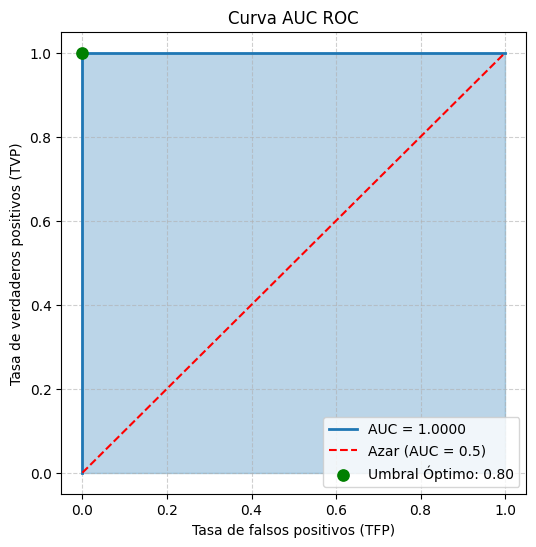

1.0


In [ ]:
# probamos

# Modelo Perfecto 
y_true_perfecto = np.array([0, 0, 1, 1])
scores_perfecto = np.array([0.1, 0.2, 0.8, 0.9])
print(auc_roc(y_true_perfecto, scores_perfecto)["AUC"]) 
# Debería dar 1.0